In [19]:
# importing libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
#starting colour palltee
sns.set_palette('Blues_d')

In [21]:
#reading data 
df = pd.read_csv('/workspaces/Exploratry_Data_California_Analysis-/Data/california_housing_prices.csv')

In [22]:
# inspecting first 10 records of California Housing Dataset
df.head(10)

,longitude,latitude,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value,ocean_proximity
0,-122.23,37.88,41.0,880.0,129.0,322.0,126.0,8.3252,452600.0,NEAR BAY
1,-122.22,37.86,21.0,7099.0,1106.0,2401.0,1138.0,8.3014,358500.0,NEAR BAY
2,-122.24,37.85,52.0,1467.0,190.0,496.0,177.0,7.2574,352100.0,NEAR BAY
3,-122.25,37.85,52.0,1274.0,235.0,558.0,219.0,5.6431,341300.0,NEAR BAY
4,-122.25,37.85,52.0,1627.0,280.0,565.0,259.0,3.8462,342200.0,NEAR BAY
5,-122.25,37.85,52.0,919.0,213.0,413.0,193.0,4.0368,269700.0,NEAR BAY
6,-122.25,37.84,52.0,2535.0,489.0,1094.0,514.0,3.6591,299200.0,NEAR BAY
7,-122.25,37.84,52.0,3104.0,687.0,1157.0,647.0,3.1200,241400.0,NEAR BAY
8,-122.26,37.84,42.0,2555.0,665.0,1206.0,595.0,2.0804,226700.0,NEAR BAY
9,-122.25,37.84,52.0,3549.0,707.0,1551.0,714.0,3.6912,261100.0,NEAR BAY


In [23]:
# inspecting shape # df.shape[0,1] 0 array points to row and 1 points to column
print (f'california housing dataset contains {df.shape[0]} rows and {df.shape[1]} columns' )

california housing dataset contains 20640 rows and 10 columns


In [24]:
# inspecting for duplicate records
print(f'California housing dataset contains {sum(df.duplicated())} duplicate records.')

California housing dataset contains 0 duplicate records.


In [25]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 20640 entries, 0 to 20639
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   longitude           20640 non-null  float64
 1   latitude            20640 non-null  float64
 2   housing_median_age  20640 non-null  float64
 3   total_rooms         20640 non-null  float64
 4   total_bedrooms      20433 non-null  float64
 5   population          20640 non-null  float64
 6   households          20640 non-null  float64
 7   median_income       20640 non-null  float64
 8   median_house_value  20640 non-null  float64
 9   ocean_proximity     20640 non-null  str    
dtypes: float64(9), str(1)
memory usage: 1.6 MB


In [26]:
#missing records isna represents NaN values and we are summing those NaN values of all columns
df.isna().sum()

longitude               0
latitude                0
housing_median_age      0
total_rooms             0
total_bedrooms        207
population              0
households              0
median_income           0
median_house_value      0
ocean_proximity         0
dtype: int64

In [27]:
# statistical description
df[['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']].describe()

,housing_median_age,total_rooms,total_bedrooms,population,households,median_income,median_house_value
count,20640.000000,20640.000000,20433.000000,20640.000000,20640.000000,20640.000000,20640.000000
mean,28.639486,2635.763081,537.870553,1425.476744,499.539680,3.870671,206855.816909
std,12.585558,2181.615252,421.385070,1132.462122,382.329753,1.899822,115395.615874
min,1.000000,2.000000,1.000000,3.000000,1.000000,0.499900,14999.000000
25%,18.000000,1447.750000,296.000000,787.000000,280.000000,2.563400,119600.000000
50%,29.000000,2127.000000,435.000000,1166.000000,409.000000,3.534800,179700.000000
75%,37.000000,3148.000000,647.000000,1725.000000,605.000000,4.743250,264725.000000
max,52.000000,39320.000000,6445.000000,35682.000000,6082.000000,15.000100,500001.000000


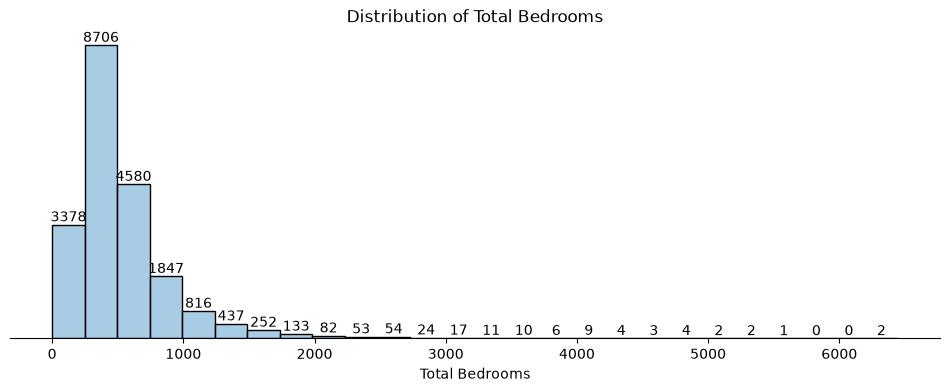

In [28]:

# what is the concentration / distribution of total_bedrooms across housing blocks?
plt.figure(figsize = (12, 4))

ax = sns.histplot(data = df, x = 'total_bedrooms', binwidth = 250)

# data labels
for p in ax.patches:
  ax.text(p.get_x() + p.get_width() / 2, p.get_height(), f'{int(p.get_height())}', ha = 'center', va = 'bottom')

plt.title('Distribution of Total Bedrooms')
plt.xlabel('Total Bedrooms')
plt.ylabel('')
plt.yticks([])

plt.gca().spines[['top', 'right', 'left']].set_visible(False)

plt.show() 
#this data is not balanced as right tables are all outliers , so we should use middled point means median values that will make more sense

In [29]:
#inputing missing values in total_besdrooms with median values
df['total_bedrooms'] = df['total_bedrooms'].fillna(df['total_bedrooms'].median())


In [30]:
df.isna().sum()

longitude             0
latitude              0
housing_median_age    0
total_rooms           0
total_bedrooms        0
population            0
households            0
median_income         0
median_house_value    0
ocean_proximity       0
dtype: int64

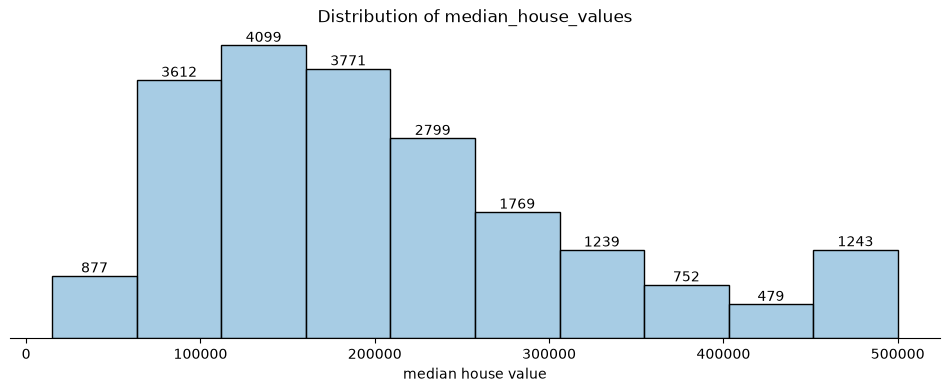

In [31]:
# how are housing values distributed across california? hitrogram as we have continuose flow of data in median house values
plt.figure(figsize = (12, 4))

ax = sns.histplot(data = df, x = 'median_house_value', binwidth = 50000) # binwidth is usually taken from after checking std normally

# data labels
for p in ax.patches:
  ax.text(p.get_x() + p.get_width() / 2, p.get_height(), f'{int(p.get_height())}', ha = 'center', va = 'bottom')

plt.title('Distribution of median_house_values')
plt.xlabel('median house value')
plt.ylabel('')
plt.yticks([])

plt.gca().spines[['top', 'right', 'left']].set_visible(False)

plt.show() 

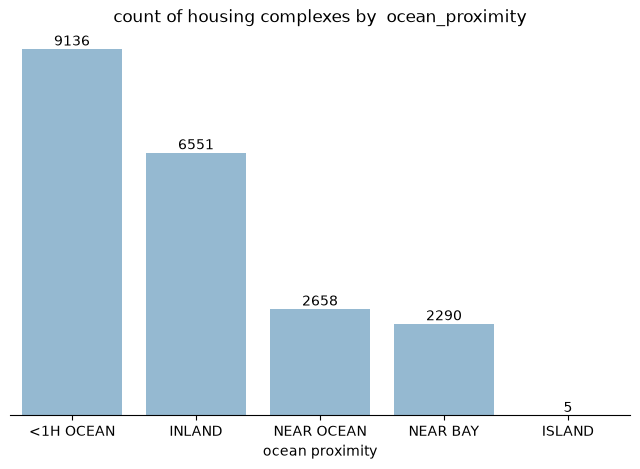

In [32]:
#hou many housing complexes are falls by ocean proximity category,countplot to see count of house
plt.figure(figsize = (8, 5))

ax = sns.countplot(data = df, x = 'ocean_proximity', order = df['ocean_proximity'].value_counts().index)

for p in ax.patches:
  ax.text(p.get_x() + p.get_width() / 2, p.get_height(), str(int(p.get_height())), ha = 'center', va = 'bottom')

plt.title('count of housing complexes by  ocean_proximity')
plt.ylabel('')
plt.xlabel('ocean proximity')
plt.yticks([])

plt.gca().spines[['top', 'right', 'left']].set_visible(False)

plt.show()

In [33]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

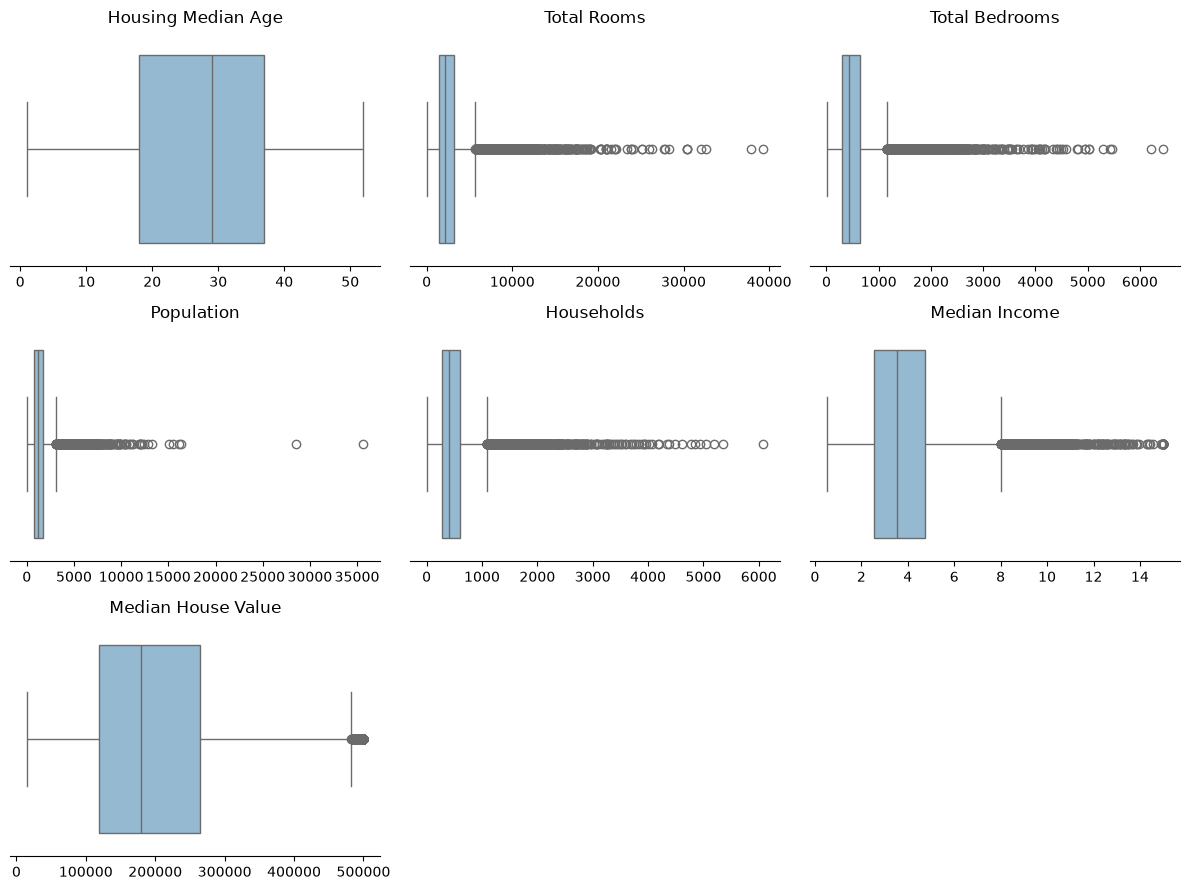

In [34]:
# outlier detection using boxplots, ocean proximity this will not apply as it is str and also latittude and logtitude are co ordinagtes so they also not applied, 7 visualization then
fig, axs = plt.subplots(nrows =3 , ncols =3 , figsize = (12,9)) #12,9 --> this 9 values should be always the numbers of subplot and the fist values should be something which will divided by the second value
# here we are making a big plot so we can fit all 3 visuals
# here we are making a big plot so we can fit all 7 visuals
#subplots have 3 rows and 3 columns means 9 small subplots inside a big plot
#we will use first 7 out of those 9 subplots

sns.boxplot( data = df , x = 'housing_median_age', ax = axs[0][0]) 
#ax describes axis like in which subplot you want the visualization so 3*3=9  metric means 00,01,02,10,11 so on, so that will position of the subplot
# we have to mention that position for boxplots to come to a subplot 
axs[0][0].set_title('Housing Median Age')
axs[0][0].set_xlabel('')
axs[0][0].set_ylabel('')
axs[0][0].set_yticks([])
axs[0][0].spines[['top', 'left', 'right']].set_visible(False)
# gcs is nit required here as we are already giving co-ords here


sns.boxplot(data = df, x = 'total_rooms', ax = axs[0][1])
axs[0][1].set_title('Total Rooms')
axs[0][1].set_xlabel('')
axs[0][1].set_ylabel('')
axs[0][1].set_yticks([])
axs[0][1].spines[['top', 'left', 'right']].set_visible(False)

sns.boxplot(data = df, x = 'total_bedrooms', ax = axs[0][2])
axs[0][2].set_title('Total Bedrooms')
axs[0][2].set_xlabel('')
axs[0][2].set_ylabel('')
axs[0][2].set_yticks([])
axs[0][2].spines[['top', 'left', 'right']].set_visible(False)

sns.boxplot(data = df, x = 'population', ax = axs[1][0])
axs[1][0].set_title('Population')
axs[1][0].set_xlabel('')
axs[1][0].set_ylabel('')
axs[1][0].set_yticks([])
axs[1][0].spines[['top', 'left', 'right']].set_visible(False)

sns.boxplot(data = df, x = 'households', ax = axs[1][1])
axs[1][1].set_title('Households')
axs[1][1].set_xlabel('')
axs[1][1].set_ylabel('')
axs[1][1].set_yticks([])
axs[1][1].spines[['top', 'left', 'right']].set_visible(False)

sns.boxplot(data = df, x = 'median_income', ax = axs[1][2])
axs[1][2].set_title('Median Income')
axs[1][2].set_xlabel('')
axs[1][2].set_ylabel('')
axs[1][2].set_yticks([])
axs[1][2].spines[['top', 'left', 'right']].set_visible(False)

sns.boxplot(data = df, x = 'median_house_value', ax = axs[2][0])
axs[2][0].set_title('Median House Value')
axs[2][0].set_xlabel('')
axs[2][0].set_ylabel('')
axs[2][0].set_yticks([])
axs[2][0].spines[['top', 'left', 'right']].set_visible(False)

axs[2][1].set_visible(False) # to hide the [2][1] box from big plot
axs[2][2].set_visible(False) # to hide the [2][1] box from big plot

plt.tight_layout()
#tight_layout() looks at all the elements (titles, labels, ticks) and resizes the subplot positions to fit them neatly inside the figure.
#Without tight_layout(), the titles and labels may overlap. With it, everything is spaced nicely.
plt.show()

In [35]:
#what enumerate does , it is showing the incex location of items in list
my_list =['A', 'B', 'C', 'D', 'E']

for i , item in  enumerate(my_list):
    print(f'{i} --> {item}')

0 --> A
1 --> B
2 --> C
3 --> D
4 --> E


In [36]:
# outlier treatment
#outliers are data which exist beyond the 25-75% quota , basically all these small balls you can in see in box plot above
# why we need to treat them, ex - 2+2=4 usually but if we have outliers we will see 2+2=4.2, so we don't want that extra data when we are creating modules/modles out of this data 
cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

#here we wil first create  IQR(internal quantile range) by measuring distance between q3 and q1(q3-q1)
#q3 is 75% point of box plot and q1 is 25% point of box plot
#then we will measure the max(high) point and low(lower)point of whiskers (the straing line on both sides of box plot)
#after that we will replace all outliers (points outside of whiskers) with the lowest and highest point of whiskers
#by this way we will remove all oultliers and our models will much cleaner

for col in cols: # we need to treat all columns so we need for loop
        q1  = df[col].quantile(0.25) #taking 25% data of box plot
        q3  = df[col].quantile(0.75) #taking 75% data of the box plot
        iqr = q3 - q1
                

        lower_limit = q1 - (1.5 * iqr) #it is the lower limit of the whisker of the box plot
        upper_limit = q3 + (1.5 * iqr) #it is the upper limit of the whisker of the box plot
       
        df[col] = np.where(df[col] < lower_limit, lower_limit, df[col]) 
        #here it is saying that col (it is one element of the list) of the cols list will be replaced with lower limit if it is lesser than col other wise col element will remain.
        #np>where(first state the codition,if mets condition then this values,otherwise other value)
        df[col] = np.where(df[col] > upper_limit, upper_limit, df[col])
        #same as lower_limit


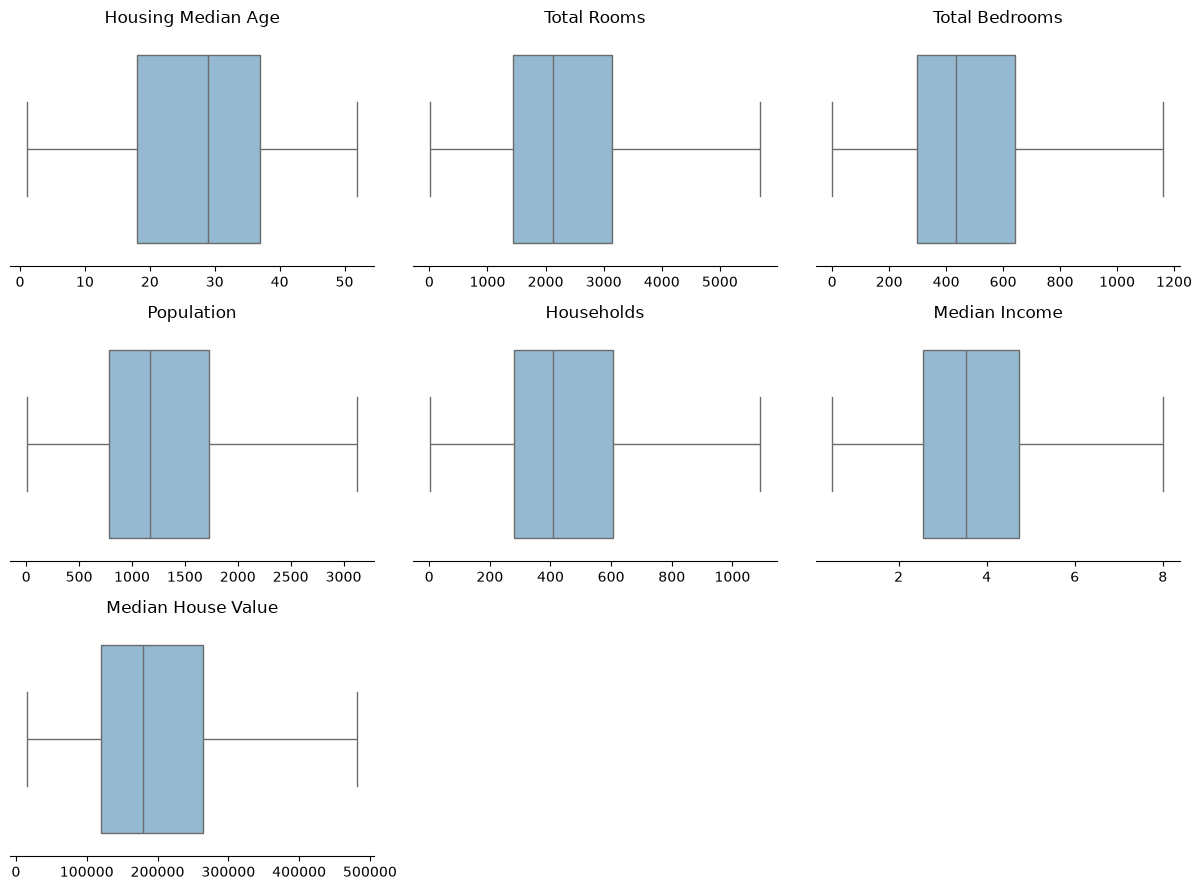

In [37]:
# outlier detection using boxplots using for loop keeping this one here in pratice session
cols = ['housing_median_age', 'total_rooms', 'total_bedrooms', 'population', 'households', 'median_income', 'median_house_value']

fig, axs = plt.subplots(nrows = 3, ncols = 3, figsize = (12, 9))
axs = axs.flatten() # this is to single direction metric as 2 directional metric doesn not work with for as it works one by one

for i, col in enumerate(cols):
  #i is index and col is the column which will take columns names from cols list,it assigns all the col from cols one number like 1 for house median age and so on
  # as enumerate popultaes index values automatically for the data, so that's why it is assigning the col from cols list to 1,2 numbers

    sns.boxplot(data = df, x = col, ax = axs[i]) #col will take the columns names from cols list and ax will assign with that 0,1,2 number of firts line
    axs[i].set_title(col.replace('_', ' ').title()) # here we have take col names then replace the _ of the names in cols list with space and then add title() so every first letter of words becomes capital
    axs[i].set_xlabel('')
    axs[i].set_ylabel('')
    axs[i].set_yticks([])
    axs[i].spines[['top', 'left', 'right']].set_visible(False)

for j in range(len(cols), len(axs)):
 # here j variable staring at lenght of cols list which 7 and then goes until lenght of axs which is 8 (all 9 value) , so means it will target mainly 7,8 values (0-8 values)
    axs[j].set_visible(False) # then we are making both those box invisible

plt.tight_layout()
plt.show() # running code again without outliers

In [38]:
df.columns

Index(['longitude', 'latitude', 'housing_median_age', 'total_rooms',
       'total_bedrooms', 'population', 'households', 'median_income',
       'median_house_value', 'ocean_proximity'],
      dtype='str')

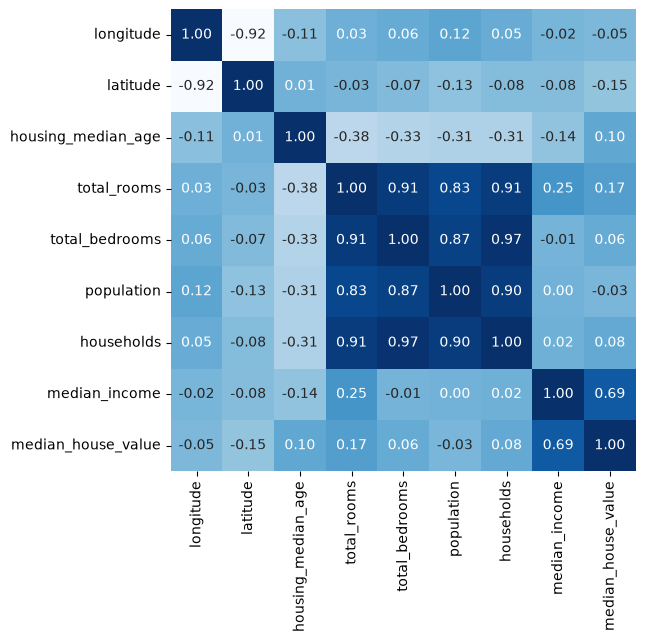

In [39]:
# correlation plot/heatmap - to see correlation between all numerical values
plt.figure(figsize = (6, 6))#to set the size
sns.heatmap(df.drop('ocean_proximity', axis = 1).corr(), annot = True, fmt = '.2f', cmap = 'Blues', cbar = False)
#here we are first droping ocean proximity as it is str , we are searching it by column that's why axis = 1, axis=0 is row
#annot = true is to show numbers inside the small boxes, fmt=.2f% to show 2 decimal values after . , cmap = blues is for colurs,cbar -flas to do not show the colour bar which describes which means which values in heatmap
plt.show()

#longitude and latitude are highly negative correlated with other, one increase so other decreases
#total rooms,total bedrooms,population and households are highly correlated as all are linked with each other
#median house values and meadian income are correlated as you earn more than you can buy house 

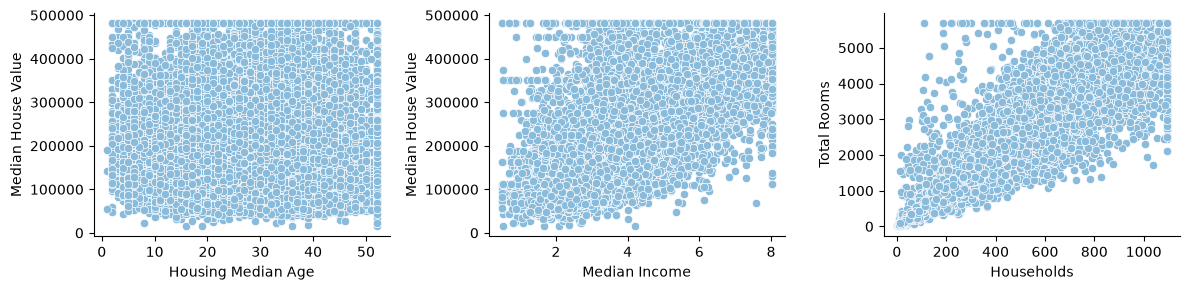

In [40]:
# observing correlation through scatterplots
fig, axs = plt.subplots(nrows =1 , ncols =3 , figsize = (12,3)) #12,3 --> this 3 value should be always the numbers of subplot and the fist values should be something which will divided by the second value
# here we are making a big plot so we can fit all 3 visuals
#subplots have 1 rows and 3 columns means 3*1=3 small subplots inside a big plot

sns.scatterplot(data = df, x = 'housing_median_age', y = 'median_house_value', ax = axs[0]) #axs is only 0 as there is only 1 row
#housing and meadin age have no interesting relation, that's why dots are all over the place as 10 year old house are sold as 1 lakh and also in 5lakh as well
axs[0].set_xlabel('Housing Median Age')
axs[0].set_ylabel('Median House Value')
axs[0].spines[['top', 'right']].set_visible(False)

sns.scatterplot(data = df, x = 'median_income', y = 'median_house_value', ax = axs[1])
#same here no interesting pattern,median income can be 2 lakh but people are living in 1lakh rs household and also in 5lalh rs household
axs[1].set_xlabel('Median Income')
axs[1].set_ylabel('Median House Value')
axs[1].spines[['top', 'right']].set_visible(False)

sns.scatterplot(data = df, x = 'households', y = 'total_rooms', ax = axs[2])
##here we can see some pattern, as more households are emerging also more rooms
axs[2].set_xlabel('Households')
axs[2].set_ylabel('Total Rooms')
axs[2].spines[['top', 'right']].set_visible(False)

plt.tight_layout()
plt.show()


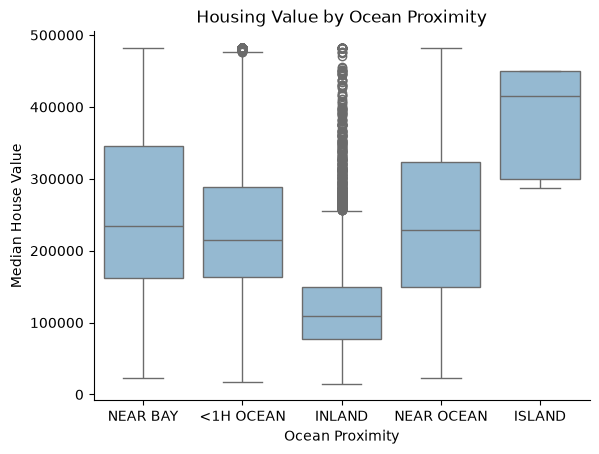

In [41]:
# how median house value changes with respect to ocean proximity
sns.boxplot(data = df, x = 'ocean_proximity', y = 'median_house_value')
plt.title('Housing Value by Ocean Proximity')
plt.xlabel('Ocean Proximity')
plt.ylabel('Median House Value')
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()
#here we can see if we live near bay, Less than 1 house ocen and also near ocean 50%(median)is almost same(250,000 rs)
#but inland median is 1lakh and in island median is 4lakh lamost double than other three, these shows which are most expensive places to stay
#but if we see in inland there are lot more outliers , means there are lot of variety prices houses are in inland 
#but other places will have somewthat similar price range houses espeically for island it is too restriced in prices

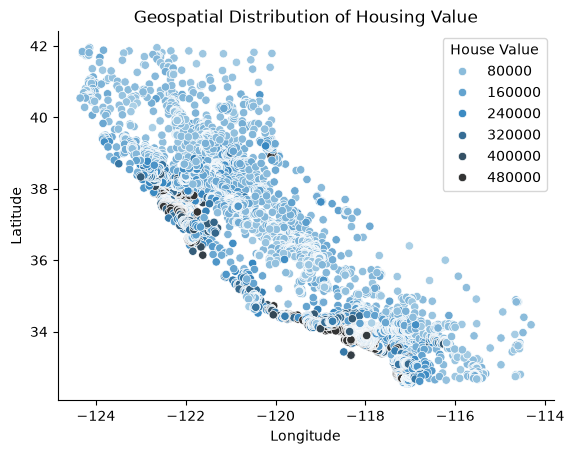

In [42]:
# geospatial distribution  - to show the map of kinda thing
sns.scatterplot(data = df, x = 'longitude', y = 'latitude', hue = 'median_house_value', palette = 'Blues_d')
# x = logtitude and y - latitude creates the base map
# now we are changing the colours according the median house values (hue changes the colour using numerical values)
# here we can see more darker colours are in the middle near the left side, so we can assume that place where we have good beaches or more places to visit of california(darkers colours are higher values and lighter are lower values)

plt.title('Geospatial Distribution of Housing Value')
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.legend(title = 'House Value') # to add the title to values which describe the coliurs of median house values
plt.gca().spines[['top', 'right']].set_visible(False)
plt.show()